# Uncertainties for Silano $^{239}$Pu/$^{235}$U(n,f) cross section ratios are estimated. (Data release: LA-UR-25-32229)

In [1]:
import os
from importlib import reload
from numpy import array, shape, ones, zeros, sqrt

In [3]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [7]:
import Class_nfcs_legacy as Cnf
reload(Cnf)

<module 'Class_nfcs_legacy' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py'>

In [9]:
Einc = 4.6
Data = 1.56
statunc = 1.0 # including off-energy neutron background uncertainties (correction would be <0.1%), alpha background taken care of by PSD.
# Statistical component of det. eff. unc. included.
multscattunc = 0.0 # detailed MC simulations, enters now deteffunc.
deteffunc = 0.4 # From their report (sample roughness is missing but they include it in their uncertainty estimate). 
Ersl = 0.83*100.0/(4.6*2.355) # FWHM, so divided through 2.355
normunc_U235  = sqrt(0.32*0.32+0.05*0.05+0.36*0.36+0.14*0.14) # 0.5% total per Table 2 of LLNL-TR-2017543
normunc_Pu239 = sqrt(0.58*0.58+0.02*0.02+0.13*0.13+0.12*0.12) # 0.607 % total per Table 2 of LLNL-TR-2017543
impurityunc = 0.0
deadtimeunc = 0.0

misalignment = 0.1 #% rounded up from 0.05% to fit into GMA format.

backgroundunc = 0.25 #% from LLNL-TR-2017543, 
# "The outcome of these activation measurements was that the total background contribution to the total fission rate from room-return neutrons would be less than 0.4% without cadmium and 0.2%–0.3% with cadmium[5,"
# Test Data in same directory



### Comments:
- In their 2026 report, they are clear that this is an independent validation of the fissionTPC data set with  fission chamber and mono-energetic neutrons.
- They measured thermal and room return background with various foils, including wrapped in Cd and without. They can make a clear statement how uncertain their background is.
- They measured with foure different methods the sample mass.
- They re-aligned the sample after flipping the target with high precision. This should take care of kinematic boost and neutron beam divergence effects. Both effects were also MC simulated. The divergence was shown to be corrected well by rotating the chamber for both Pu9/U235 and Pu9/U238 ratios.
- They corrected for off-energy neutrons.
- They corrected also forward-boost, sample thickness and angular distributions with MCNP simulations of the detector efficiency.
- The neutron energy determination was measured with a scintillator and counter-checked with MCNP. The results agree well.

In [12]:
features = {'Author':['J. Silano','A. Tonchev', 'A. Ramirez', 'R. Malone'],'Year':2025,\
            'Absolute':'Yes','GMAnumber':'6005',\
            'MonitorReaction':'(92-U-235(N,F),,CS)','EXFORnumber':'None yet',\
            'AcceptedVsRejected':'accepted',\
            'Facility':['VDG','1USATNL'],'Institute':'1USATNL',\
            'Isotope':'Pu-239','quantity': 'cs', 'reaction': 'n,f',\
            'MeasurementType':'Clean ratio','ConcernEXFOR':'N/A',\
            'AcceptedVsRejected':'y',\
            'MissingCorrections':['SampleRoughness'],\
            'BackgroundCorrected':'y','MultipleScatteringCorrected':'y',\
            'AttenuationCorrected':'y','StoppingPowerCorrected':'y',\
            'SampleRoughnessCorrected':'n',\
            'AngularDistributionFissionFragmentsCorrected':'y',\
            'ForwardBoostCorrected':'y',\
            'DeadtimeCorrected':'y',\
            'ImpuritiesCorrected':'y','RandomCoincidenceCorrected':'y',\
            'SpectrumExtrapolationCorrected':'y',\
            'GeometryCorrected':'y','NeutronFluxVariationCorrected':'y',\
            'FissionDetector':{'Type':'IOCH','ParticleDetected':'FF',\
            'Efficiency':98.5,'EfficiencyMethod':['ratio method','MC','rotating chamber'],\
            'FFAbsorptionAngularDistributionMethod':'MC',\
            'AngularAcceptaneofFF':'unknown',\
            'Gas':{'Type':['argon','methane'],'Purity':[90,10],'Pressure':'unknown','Pressure_unit':'N/A'},\
            'Size':{'geometry':'cylinder','height':1.73,'diameter':2.5,'diameter_unit':'cm'},\
                               'NoPhotomultipliers':1,\
            'Weight':'unknown','StructuralMaterial':'unknown','ReferenceDetector':'IOCH'},\
            'NeutronFluxDetector':{'Type':'SCIN','Number':1.0,'ParticleDetected':'n',\
            'Efficiency':'unknown','ResponseDeterminationMethod':'unknown',\
            'EfficiencyDeterminationMethod':'clean ratio','Angle':'unknown',\
            'Gas':{'Type':'N/A','Purity':'N/A','Pressure':'N/A'},\
            'Size':{'geometry':'unknown','diameter':'N/A','diameter_unit':'N/A'},\
            'NoPhotomultipliers':'unknown','Photomultipliers':'unknown',\
            'Weight':'unknown','StructuralMaterial':'unknown',\
            'ReferenceDetector':'unknown','ReferenceReaction':'unknown'},\
            'Shielding':{'Material':['Pb','Cd'],\
            'Size':{'Geometry':'unknown','Length':'unknown','Length_unit':'unknown'},'DistanceFromNeutronDetector':'close',\
            'Purpose':'Background supression'},\
            'Sample':{'Activity':'unknown','Activity_unit':'N/A','Reused':'no',
                     'Form':'deposits','Mass':8.49,'Mass_unit':'mug','Diameter':1.27,'Diameter_unit':'cm','Thickness':10.0,'Thickness_unit':'mug/cm2','Homogenity':'unknown',\
            'Contaminants':{'239Pu':99.948,'240Pu':0.049,'241Pu':0.003,'235U':'unknown'},'BackingMaterial':'Ti','BackingDiameter':25.4,'Diameter_unit':',m',\
            'BackingThickness':0.013,'BackingThicknessUnit':'cm','DecayDeterminationMethod':'calculated','Configuration':'back-to-back',\
            'Fabrication':'electroplated','ImpurityDetermination':'mass spectrometry','NumberOfAtomsInSampleDeterminationTechnique':['low-geometry alpha spectrometry']},\
            'BackgroundMethods':{'General':['measured','TOF cut','fit','Cd shield'],'Wraparound':'N/A','alpha':'PSD',\
            'Gamma':'unknown','RandomCoincidence':'fit'},\
            'MultipleScatteringMethods':{'InSample':['Design','MC'],'Surrounding':['Design','MC']},\
            'AttenuationMethods':{'InSample':['Design','MC'],'Surrounding':['Design','MC']},\
            'DeadtimeDeterminationMethod':'Calculated',\
            'EnergyDetermination':'mono-energetic',\
            'NeutronBeam':{'Facility':['VDG','1USATNL'],'PulseWidth':2.0,'PulseWidthUnit':'ns',\
                          'NeutronProducingReaction':'d,2H','Target':'2H',\
                          'EnergySpread':'unknown','Monitor':'235U IOCH',\
                           'Diameter':'unknown','Diameter_unit':'N/A','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',\
             'TOFLength':{'Value':3.5,'Unit': 'cm','Unc':'unknown','Unit_Unc':'N/A'},\
             'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
            't0Determination':'unknown'}
}


Testing covariance matrix of type Positive_fully:
Covariance is 1-dimensional. No symmetry and postive semi-definiteness checked.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
Testing enrsl covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing cov_eunc covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing ratio covariance matrix:
Ok: Matrix is symmetric.
Ok:

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/BasicPhysicsFunctions.py:230: RuntimeWarning: divide by zero encountered in scalar divide
  data_derivative[index] = (data[index+1]-data[index])/(lattice[1+index]-lattice[index])
/Users/dneudecker/Documents/Codes/ARIADNE-github/src/BasicPhysicsFunctions.py:230: RuntimeWarning: invalid value encountered in scalar divide
  data_derivative[index] = (data[index+1]-data[index])/(lattice[1+index]-lattice[index])


{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
Testing covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


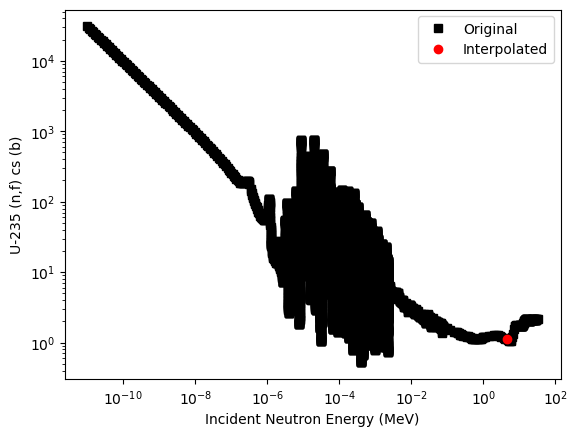

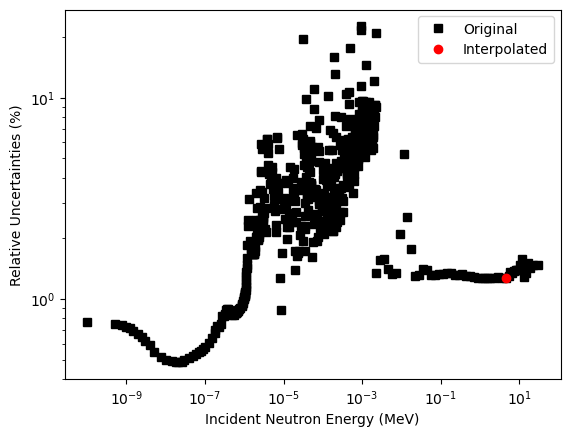

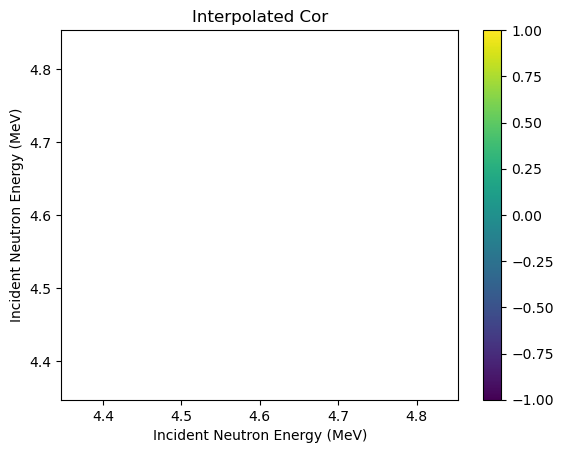

Testing interpolated covariance matrix of reference reaction:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_Silano2025/DS6005.xml
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_Silano2025/DS6005EUCLID.json
{'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.1'}
{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_Silano2025/DS6005ratiodataEUCLID.json

Output file saved in file: /Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Pu-239/nfcs_Silano2025/Partial_Unc.dat
No correlation mat

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


No correlation matrices plotted as only one data value.


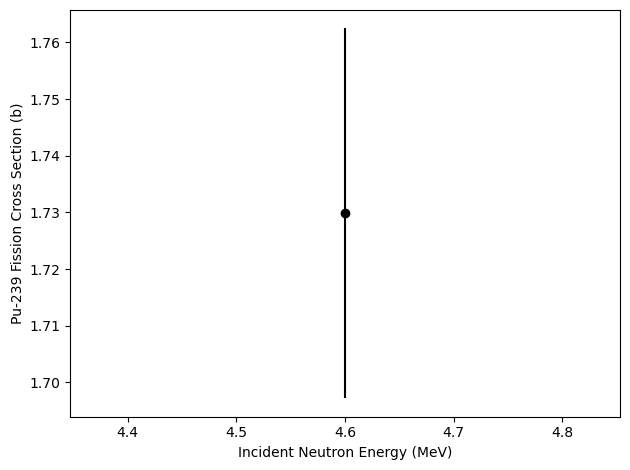

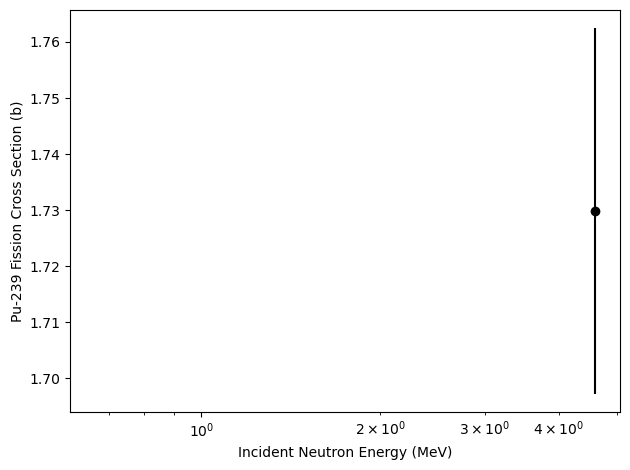

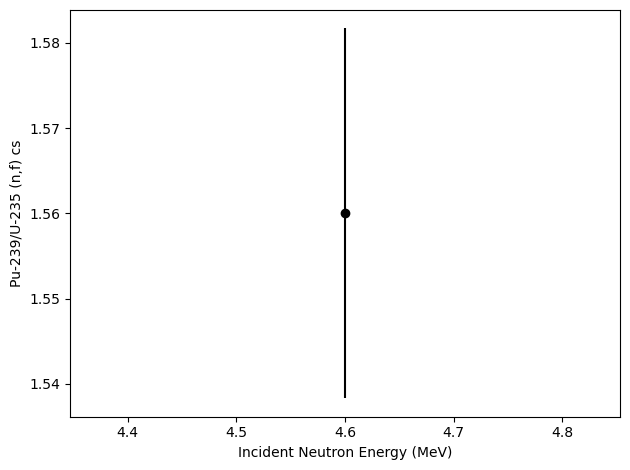

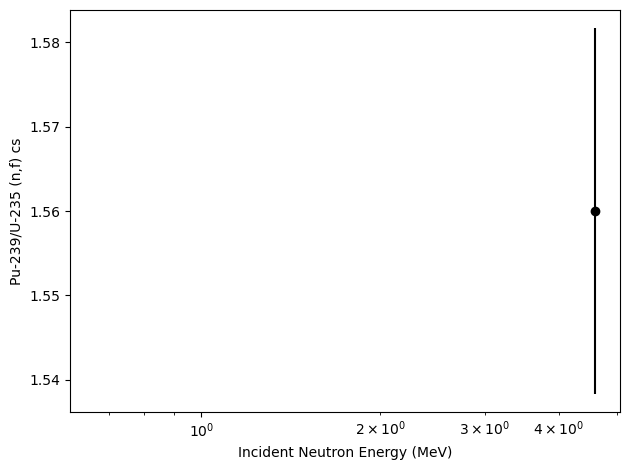

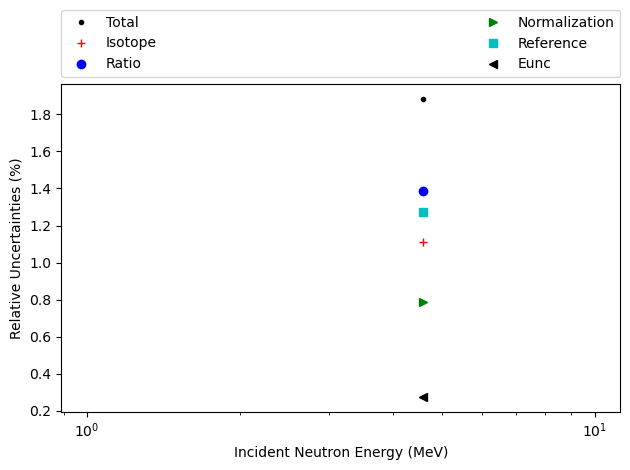

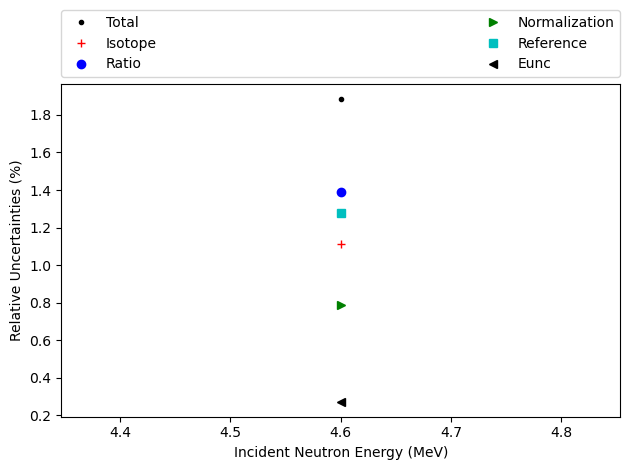

In [16]:
Documentation = """EXFOR No. = none; Journal article = J. Silano et al., LLNL-TR- 2011630 
(2025); C. Bhatia et al., NIMA 757 (2014), p. 7-19; J.A. Silano et al., NIMA 1063 (2024) 
169234; LLNL-TR-2017543 (2026). This data set was provided in private communication with the literature described
above. The first information was rough (with lots of information by the authors themselves). Then, they provided a very nice write-up in 2026 in addition.
- In their 2026 report, they are clear that this is an independent validation of the fissionTPC data set with  fission chamber and mono-energetic neutrons.
- They measured thermal and room return background with various foils, including wrapped in Cd and without. They can make a clear statement how uncertain their background is.
- They measured with foure different methods the sample mass.
- They re-aligned the sample after flipping the target with high precision. This should take care of kinematic boost and neutron beam divergence effects. Both effects were also MC simulated. The divergence was shown to be corrected well by rotating the chamber for both Pu9/U235 and Pu9/U238 ratios.
- They corrected for off-energy neutrons.
- They corrected also forward-boost, sample thickness and angular distributions with MCNP simulations of the detector efficiency.
- The neutron energy determination was measured with a scintillator and counter-checked with MCNP. The results agree well.
In 2025, only statistical and systematic uncertainties were provided that were later more detailed. The authors 
were very responsive to my questions.
Based on this email, the statistical unc. include the off-energy background and the statistical component of the detector efficiency uncertainty.
Multiple scattering unc. are negligible per quick simulations; thus, I assume the template value as a stand-in as not yet simulated in detail.
I assume the template detector efficienct unc. at the lower end as they have thought about part of it (stopping power),
but not all. For instance, angular distribution effects and sample roughness were not considered.
"""

# You need to re-check uncertainties and correlate them.

general_info = {'name': 'DS6005', 'isotope': 'Pu-239', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6005.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

 # ASSUMPTION: Full correlation between eunc
einc_unc = {'en_err' : {'enerr_unc': array(Ersl*0.2),'enerr_unc_unit': '%','enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.1'}

normunc  = sqrt(normunc_U235*normunc_U235+normunc_Pu239*normunc_Pu239)
norm_unc = {'value': normunc, 'unit':'%'}

reference = {'isotope': 'U-235','quantity': 'cs', 'reaction': 'n,f','identifier':'ENDF/B-VIII.0'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc,\
           'values':array([statunc,misalignment,deteffunc,backgroundunc]).transpose(),
           'units':['%','%','%','%'],
           'type':['Diagonal','Gaussian','Gaussian','Gaussian'],
           'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0],}}
data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }

DS6005_nfcs = Cnf.nfcs_cleanratioabsolute(general_info,data,unc_iso,reference,features)

In [18]:
dim = 1

In [20]:
GMAnewnumber='6005'
year = '2026'
authors = 'J.Silano'
journal = 'LLNL-TR2017543(2026)'
uncertainty_descriptor = ['UNCERTAINTIES',\
 '1 U-235 no. of atoms in sample unc., 2. Pu-239 no. of atoms in sample unc',\
 'FISSION CHAMBER EFFICIENCY WAS MODELED, INCLUDING FORWARD BOOST.',\
 'ATOM NUMBER RATIO CHARACTERIZED BY ALPHA SPECTROMETER.',\
 '2 Enrsl explicitly given, Eunc is 0.2*Enrsl',\
 '3 Statistical unc. encompasses counting statistics and stat. components',\
 'of off-energy background and det. eff.',\
 '4 Unc. due to misalignment after rotation (correcting forward/boost, beam divergence)',\
 '5 Det. eff. unc. by authors 0.4% (significant MCNP studies)',\
 '6 Background unc. by authors (significant measurement and MCNP studies)']
normalizationunc = [normunc_U235,normunc_Pu239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0:3,:] = zeros([3,3],dtype=float)
Enerr = 0.2*Ersl
Enrsl = Ersl*ones(dim,dtype=float)
uncertainties = zeros([dim,10],dtype=float)
uncertainties[:,:4] = array([statunc,misalignment,deteffunc,backgroundunc]).transpose()

controlnumber = [0,0,9,1,1,1,0,0,0,0,0]

abs_shape = 'absolute'

In [22]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Enerr,Enrsl,uncertainties,controlnumber,normalizationunc)

5
5
5
5
5
5
5
5
5
5
